# Notebook 4: Stress Tests and Failure Analysis

This notebook evaluates the trained HumanMAC model under controlled input corruptions to identify failure modes before deployment. It measures how prediction quality (ADE, FDE) degrades when input deviates from clean test conditions.

We apply four categories of stress tests:

1. **Gaussian noise injection**: Additive noise at varying sigma applied to observed joint coordinates, simulating motion capture sensor noise.
2. **Joint masking (dropout)**: Random subsets of joints are zeroed out in the observation window, simulating partial occlusion or sensor failure.
3. **Out-of-distribution (OOD) input**: Temporally shuffled and constant-pose sequences that violate the temporal coherence the model was trained on.
4. **Action-class rarity**: Per-action ADE/FDE breakdown to identify classes where the model underperforms due to limited training representation.

Additionally, this notebook measures inference latency (p50/p90) and throughput on the available GPU hardware.

For each condition we generate 50 prediction samples per test sequence (following the paper's evaluation protocol) and report ADE and FDE compared against the clean baseline.

This analysis feeds into Section 8.1 (Anticipated Failures and Risk Analysis) and Section 8.2.4 (Quantitative Robustness Results) of the project report.

## Section 1: Imports and Setup

Standard imports matching the training notebook. The HumanMAC repo root is added to `sys.path` so local modules (models, utils, data_loader) resolve correctly.

In [1]:
import sys, os, copy, time
import numpy as np
import torch
import matplotlib.pyplot as plt
import pandas as pd
from types import SimpleNamespace
from tqdm import tqdm

REPO_ROOT = os.path.abspath('../HumanMAC/')
if REPO_ROOT not in sys.path:
    sys.path.insert(0, REPO_ROOT)

from config import Config, update_config
from utils import create_logger, seed_set, padding_traj, post_process
from utils.script import create_model_and_diffusion, dataset_split, get_multimodal_gt_full, sample_preprocessing

print(f'PyTorch version : {torch.__version__}')
print(f'CUDA available  : {torch.cuda.is_available()}')
if torch.cuda.is_available():
    print(f'GPU             : {torch.cuda.get_device_name(0)}')

<IPython.core.display.Javascript object>

PyTorch version : 1.7.1+cu110
CUDA available  : True
GPU             : NVIDIA GeForce RTX 4090


## Section 2: Configuration and Checkpoint Loading

We reuse the same config (`cfg/h36m.yml`) and runtime args from training. The EMA checkpoint from the best-performing epoch is loaded. `CKPT_PATH` should point to the saved `.pt` file (e.g., `ckpt_ema_1000.pt`).

In [ ]:
seed_set(0)

# Change to repo root so Config can find ./cfg/h36m.yml and checkpoints resolve correctly
os.chdir(REPO_ROOT)

args = {
    'cfg': 'h36m', 'mode': 'test', 'iter': 0, 'seed': 0,
    'device': torch.device('cuda') if torch.cuda.is_available() else torch.device('cpu'),
    'multimodal_threshold': 0.5, 'multimodal_th_high': 0.1,
    'milestone': [75, 150, 225, 275, 350, 450], 'gamma': 0.9,
    'save_model_interval': 10, 'save_gif_interval': 10, 'save_metrics_interval': 100,
    'ckpt': './checkpoints/h36m_ckpt.pt',
    'ema': True, 'vis_switch_num': 10, 'vis_col': 5, 'vis_row': 3,
}

cfg = Config('h36m', test=False)
cfg = update_config(cfg, args)

print(f'Device          : {cfg.device}')
print(f't_his / t_pred  : {cfg.t_his} / {cfg.t_pred}')
print(f'n_pre (DCT)     : {cfg.n_pre}')
print(f'Joint count     : {cfg.joint_num}')

Device          : cuda
t_his / t_pred  : 25 / 100
n_pre (DCT)     : 20
Joint count     : 16


In [4]:
# Build model and diffusion, then load trained EMA checkpoint
model, diffusion = create_model_and_diffusion(cfg)

# Update this path to match your saved checkpoint
CKPT_PATH = os.path.join(cfg.model_path, 'ckpt_ema_990.pt')     # Trained from training_humanmac notebook
state_dict = torch.load(CKPT_PATH, map_location=cfg.device)
model.load_state_dict(state_dict)
model.eval()

total_params = sum(p.numel() for p in model.parameters())
print(f'Loaded checkpoint: {CKPT_PATH}')
print(f'Total parameters : {total_params/1e6:.2f}M')

Loaded checkpoint: results/test_4/models/ckpt_ema_990.pt
Total parameters : 28.40M


## Section 3: Dataset and Multimodal Ground Truth

Load the Human3.6M test split and build the multimodal ground-truth dictionary used for ADE/FDE computation. `dataset_multi_test` groups test sequences by similar starting poses (pairwise L2 distance < 0.5) for MMADE/MMFDE.

In [5]:
dataset, dataset_multi_test = dataset_split(cfg)
args_ns = SimpleNamespace(**args)

import logging
logger = logging.getLogger('stress_test')
logger.setLevel(logging.INFO)
if not logger.handlers:
    logger.addHandler(logging.StreamHandler())

multimodal_dict = get_multimodal_gt_full(logger, dataset_multi_test, args_ns, cfg)

# all_data: (N, t_his+t_pred, 48) -- root-removed, flattened joint coords
data_group = multimodal_dict['data_group']
gt_group   = multimodal_dict['gt_group']
traj_gt_arr = multimodal_dict['traj_gt_arr']
num_samples = multimodal_dict['num_samples']

print(f'Test sequences  : {num_samples}')
print(f'data_group shape: {data_group.shape}')
print(f'gt_group shape  : {gt_group.shape}')

preparing full evaluation dataset...
#1 future: 73/5168
#<10 future: 1011/5168
done...


Test sequences  : 5168
data_group shape: (5168, 125, 17, 3)
gt_group shape  : (5168, 100, 48)


## Section 4: Evaluation Helpers

`get_prediction` takes a batch of trajectory data, applies the HumanMAC DDIM sampling pipeline, and returns predicted future motion in joint-coordinate space. `evaluate_ade_fde` loops over K=50 samples and computes per-sequence ADE/FDE, returning the mean and per-sequence arrays for failure-case analysis.

Key variables:
- `K`: number of prediction samples per test sequence (50, matching paper protocol)
- `traj_est`: predicted trajectory after inverse DCT, shape (K, N, t_pred, 48)

In [6]:
def get_prediction(data, model_select, cfg, diffusion):
    """Run DDIM sampling on a batch of trajectory data.
    
    Args:
        data: (N, t_his+t_pred, joints, 3) raw trajectory array
    Returns:
        traj_est: (1, N, t_his+t_pred, 48) predicted full trajectory
    """
    traj_np = data[..., 1:, :].transpose([0, 2, 3, 1])
    traj = torch.tensor(traj_np, device=cfg.device, dtype=torch.float32)
    traj = traj.reshape([traj.shape[0], -1, traj.shape[-1]]).transpose(1, 2)

    mode_dict, traj_dct, traj_dct_cond = sample_preprocessing(traj, cfg, mode='metrics')
    sampled_motion = diffusion.sample_ddim(model_select, traj_dct, traj_dct_cond, mode_dict)

    traj_est = torch.matmul(cfg.idct_m_all[:, :cfg.n_pre], sampled_motion)
    traj_est = traj_est.cpu().numpy()
    traj_est = traj_est[None, ...]
    return traj_est

In [7]:
def evaluate_ade_fde(data_group, gt_group, traj_gt_arr, num_samples, model_select, cfg, diffusion, K=50):
    """Compute ADE, FDE, MMADE, MMFDE over K=50 prediction samples.
    
    Returns:
        results: dict with mean ADE, FDE, MMADE, MMFDE
        per_seq_ade: (num_samples,) per-sequence best ADE for failure analysis
        per_seq_fde: (num_samples,) per-sequence best FDE
    """
    pred_all = []
    for i in tqdm(range(K), desc='Sampling'):
        pred_i = get_prediction(data_group, model_select, cfg, diffusion)
        pred_all.append(pred_i)

    # pred_all: (K, N, t_his+t_pred, 48)
    pred_all = np.concatenate(pred_all, axis=0)
    pred_all = pred_all[:, :, cfg.t_his:, :]  # future only: (K, N, t_pred, 48)

    pred_t = torch.from_numpy(pred_all).cuda()
    gt_t   = torch.from_numpy(gt_group).cuda() if not torch.is_tensor(gt_group) else gt_group.cuda()

    ade_list, fde_list, mmade_list, mmfde_list = [], [], [], []
    per_seq_ade = np.zeros(num_samples)
    per_seq_fde = np.zeros(num_samples)

    for j in range(num_samples):
        gt_multi_j = torch.from_numpy(traj_gt_arr[j]).cuda()
        gt_all_j = torch.cat([gt_multi_j, gt_t[j:j+1]], dim=0)  # (M+1, t_pred, 48)

        gt_all_j = gt_all_j[None, ...]   # (1, M+1, t_pred, 48)
        pred_j   = pred_t[:, j:j+1, :, :]  # (K, 1, t_pred, 48)

        diff = pred_j - gt_all_j  # (K, M+1, t_pred, 48)
        dist = torch.linalg.norm(diff, dim=3)  # (K, M+1, t_pred)

        # ADE/FDE: best of K samples against the single GT (last entry)
        ade_k = dist[:, -1].mean(dim=1)  # (K,)
        fde_k = dist[:, -1, -1]          # (K,)
        ade_best = ade_k.min().item()
        fde_best = fde_k.min().item()

        # MMADE/MMFDE: best of K samples against each multimodal GT
        mmade_k = dist[:, :-1].mean(dim=2).min(dim=0)[0].mean().item()
        mmfde_k = dist[:, :-1, -1].min(dim=0)[0].mean().item()

        ade_list.append(ade_best)
        fde_list.append(fde_best)
        mmade_list.append(mmade_k)
        mmfde_list.append(mmfde_k)
        per_seq_ade[j] = ade_best
        per_seq_fde[j] = fde_best

    results = {
        'ADE':   np.mean(ade_list),
        'FDE':   np.mean(fde_list),
        'MMADE': np.mean(mmade_list),
        'MMFDE': np.mean(mmfde_list),
    }
    return results, per_seq_ade, per_seq_fde

## Section 5: Clean Baseline Evaluation

Run the full evaluation on unmodified test data. This establishes the reference ADE/FDE that all stress-test results will be compared against. The per-sequence arrays (`baseline_per_ade`, `baseline_per_fde`) are saved for later failure-case selection.

In [8]:
baseline_results, baseline_per_ade, baseline_per_fde = evaluate_ade_fde(
    data_group, gt_group, traj_gt_arr, num_samples, model, cfg, diffusion, K=50
)

print('Clean Baseline Results:')
for k, v in baseline_results.items():
    print(f'  {k:6s}: {v:.4f}')

Sampling: 100%|██████████| 50/50 [3:54:35<00:00, 281.50s/it]  


Clean Baseline Results:
  ADE   : 0.3691
  FDE   : 0.4776
  MMADE : 0.5103
  MMFDE : 0.5435


## Section 6: Stress Test 1 -- Gaussian Noise Injection

Additive Gaussian noise is applied to the observed frames (first 25 frames) of every test sequence. The noise is sampled as N(0, sigma^2) and added to the flattened joint coordinates (48 dims = 16 joints x 3). We test sigma values [0.01, 0.05, 0.1, 0.2, 0.5] to characterize degradation from mild sensor jitter to severe corruption.

The corrupted `data_group` is passed through the same evaluation pipeline. The `data_group` has shape (N, t_his+t_pred, joints, 3), so noise is added to `data_group[:, :t_his, 1:, :]` (observed frames, root-removed joints).

In [9]:
sigma_levels = [0.01, 0.05, 0.1, 0.2, 0.5]
noise_results = {}

for sigma in sigma_levels:
    print(f'\n--- Gaussian Noise sigma={sigma} ---')
    data_noisy = data_group.copy()
    # Add noise only to observed frames, non-root joints
    noise = np.random.randn(*data_noisy[:, :cfg.t_his, 1:, :].shape) * sigma
    data_noisy[:, :cfg.t_his, 1:, :] += noise

    res, _, _ = evaluate_ade_fde(
        data_noisy, gt_group, traj_gt_arr, num_samples, model, cfg, diffusion, K=50
    )
    noise_results[sigma] = res
    print(f'  ADE: {res["ADE"]:.4f}  FDE: {res["FDE"]:.4f}')

Sampling:   0%|          | 0/50 [00:00<?, ?it/s]


--- Gaussian Noise sigma=0.01 ---


Sampling:   0%|          | 0/50 [00:00<?, ?it/s]

  ADE: 0.4209  FDE: 0.5039

--- Gaussian Noise sigma=0.05 ---


Sampling:   0%|          | 0/50 [00:00<?, ?it/s]

...

  ADE: 1.1654  FDE: 1.0509

--- Gaussian Noise sigma=0.2 ---


Sampling:   0%|          | 0/50 [00:00<?, ?it/s]

  ADE: 3.6781  FDE: 2.3914

--- Gaussian Noise sigma=0.5 ---


Sampling: 100%|██████████| 50/50 [3:56:32<00:00, 283.84s/it]  


  ADE: 17.5621  FDE: 10.6773


In [10]:
# Clear CUDA memory
import torch

torch.cuda.empty_cache()

## Section 7: Stress Test 2 -- Joint Masking (Dropout)

Random subsets of the 16 non-root joints are zeroed out in the observed frames, simulating partial sensor failure or occlusion. We test masking rates [10%, 25%, 50%, 75%]. For each rate, the masked joints are selected randomly per sequence. Setting a joint to zero means all 3 coordinates (x, y, z) are zeroed for all 25 observed frames.

In [11]:
mask_rates = [0.10, 0.25, 0.50, 0.75]
mask_results = {}
n_joints = cfg.joint_num  # 16 non-root joints

for rate in mask_rates:
    print(f'\n--- Joint Masking rate={rate:.0%} ---')
    data_masked = data_group.copy()
    n_mask = max(1, int(n_joints * rate))

    for i in range(data_masked.shape[0]):
        # Randomly select joints to zero out (indices 1..16 in the joint dim, since 0 is root)
        masked_joints = np.random.choice(n_joints, size=n_mask, replace=False) + 1  # +1 to skip root
        data_masked[i, :cfg.t_his, masked_joints, :] = 0.0

    res, _, _ = evaluate_ade_fde(
        data_masked, gt_group, traj_gt_arr, num_samples, model, cfg, diffusion, K=50
    )
    mask_results[rate] = res
    print(f'  ADE: {res["ADE"]:.4f}  FDE: {res["FDE"]:.4f}')

Sampling:   0%|          | 0/50 [00:00<?, ?it/s]


--- Joint Masking rate=10% ---


Sampling:   0%|          | 0/50 [00:00<?, ?it/s]

  ADE: 0.5715  FDE: 0.6299

--- Joint Masking rate=25% ---


Sampling:   0%|          | 0/50 [00:00<?, ?it/s]

  ADE: 0.8907  FDE: 0.8723

--- Joint Masking rate=50% ---


Sampling:   0%|          | 0/50 [00:00<?, ?it/s]

  ADE: 1.0794  FDE: 0.9871

--- Joint Masking rate=75% ---


Sampling: 100%|██████████| 50/50 [5:09:07<00:00, 370.96s/it]  


  ADE: 1.2015  FDE: 1.0454


## Section 8: Stress Test 3 -- Out-of-Distribution Inputs

Two OOD scenarios that break the temporal coherence assumption:

1. **Temporal shuffle**: The 25 observed frames are randomly permuted per sequence, destroying motion continuity while preserving per-frame statistics.
2. **Constant pose (freeze)**: All 25 observed frames are replaced with copies of the first frame, simulating a frozen/stuck sensor.

In [12]:
# OOD 1: Temporal shuffle
print('--- OOD: Temporal Shuffle ---')
data_shuffled = data_group.copy()
for i in range(data_shuffled.shape[0]):
    perm = np.random.permutation(cfg.t_his)
    data_shuffled[i, :cfg.t_his] = data_shuffled[i, perm]

ood_shuffle_results, _, _ = evaluate_ade_fde(
    data_shuffled, gt_group, traj_gt_arr, num_samples, model, cfg, diffusion, K=50
)
print(f'  ADE: {ood_shuffle_results["ADE"]:.4f}  FDE: {ood_shuffle_results["FDE"]:.4f}')

Sampling:   0%|          | 0/50 [00:00<?, ?it/s]

--- OOD: Temporal Shuffle ---


Sampling: 100%|██████████| 50/50 [5:36:45<00:00, 404.11s/it]  


  ADE: 0.6360  FDE: 0.6036


In [13]:
# OOD 2: Constant pose (frozen sensor)
print('--- OOD: Constant Pose (Freeze) ---')
data_frozen = data_group.copy()
for i in range(data_frozen.shape[0]):
    data_frozen[i, :cfg.t_his] = data_frozen[i, 0:1]  # repeat first frame

ood_frozen_results, _, _ = evaluate_ade_fde(
    data_frozen, gt_group, traj_gt_arr, num_samples, model, cfg, diffusion, K=50
)
print(f'  ADE: {ood_frozen_results["ADE"]:.4f}  FDE: {ood_frozen_results["FDE"]:.4f}')

Sampling:   0%|          | 0/50 [00:00<?, ?it/s]

--- OOD: Constant Pose (Freeze) ---


Sampling: 100%|██████████| 50/50 [5:18:33<00:00, 382.28s/it]  


  ADE: 0.5598  FDE: 0.5721


## Section 9: Stress Test 4 -- Per-Action Class Breakdown

Human3.6M test set (Subject S5) contains 15 action classes. Some actions like "Sitting" or "SittingDown" have inherently higher motion variability. We evaluate ADE/FDE per action to identify class-rarity or difficulty-driven failures. The dataset iterator `sample_iter_action` is used to isolate sequences by action label.

In [14]:
# Get list of actions from the test dataset
actions = list(dataset['test'].data['S5'].keys()) if 'S5' in dataset['test'].data else list(
    list(dataset['test'].data.values())[0].keys()
)
print(f'Actions in test set ({len(actions)}): {actions}')

Actions in test set (30): ['Directions 1', 'Directions', 'Discussion 1', 'Discussion 2', 'Eating 1', 'Eating', 'Greeting 1', 'Greeting', 'Phoning 1', 'Phoning', 'Photo 1', 'Photo', 'Posing 1', 'Posing', 'Purchases 1', 'Purchases', 'Sitting 1', 'Sitting', 'SittingDown 1', 'SittingDown', 'Smoking 1', 'Smoking', 'Waiting 1', 'Waiting', 'WalkDog 1', 'WalkDog', 'Walking 1', 'Walking', 'WalkTogether 1', 'WalkTogether']


In [15]:
# Per-action ADE/FDE using a simplified K-sample evaluation
# For each action, sample N_act sequences and compute best-of-K ADE/FDE
K_act = 50
action_metrics = {}

for action in actions:
    print(f'\n--- Action: {action} ---')
    # Get action-specific data via the dataset's per-action sampling
    act_data_list = []
    gen = dataset['test'].sampling_generator(num_samples=2000, batch_size=64)
    
    # Use data dict directly for per-action sequences
    subj_data = dataset['test'].data
    act_seqs = []
    for subj in subj_data:
        if action in subj_data[subj]:
            seq = subj_data[subj][action]  # (frames, joints, 3)
            # Slide windows of length t_his + t_pred
            for start in range(0, seq.shape[0] - cfg.t_his - cfg.t_pred + 1, cfg.t_his):
                act_seqs.append(seq[start:start + cfg.t_his + cfg.t_pred])
    
    if len(act_seqs) == 0:
        print(f'  No sequences found, skipping.')
        continue
    
    act_seqs = np.array(act_seqs)  # (N_act, t_his+t_pred, joints, 3)
    
    # Compute ADE/FDE for this action
    # Flatten for prediction: remove root, reshape
    act_flat = act_seqs[..., 1:, :].reshape(act_seqs.shape[0], cfg.t_his + cfg.t_pred, -1)
    gt_act = act_flat[:, cfg.t_his:, :]  # (N_act, t_pred, 48)
    
    pred_act = []
    for k in range(K_act):
        traj_np = act_seqs[..., 1:, :].transpose([0, 2, 3, 1])
        traj = torch.tensor(traj_np, device=cfg.device, dtype=torch.float32)
        traj = traj.reshape([traj.shape[0], -1, traj.shape[-1]]).transpose(1, 2)
        mode_dict, traj_dct, traj_dct_cond = sample_preprocessing(traj, cfg, mode='metrics')
        sampled = diffusion.sample_ddim(model, traj_dct, traj_dct_cond, mode_dict)
        traj_est = torch.matmul(cfg.idct_m_all[:, :cfg.n_pre], sampled)
        pred_act.append(traj_est[:, cfg.t_his:, :].cpu().numpy())
    
    pred_act = np.stack(pred_act, axis=0)  # (K, N_act, t_pred, 48)
    gt_act_t = torch.from_numpy(gt_act).cuda()
    pred_act_t = torch.from_numpy(pred_act).cuda()
    
    # Best-of-K ADE/FDE per sequence, then average
    diff = pred_act_t - gt_act_t[None, ...]  # (K, N_act, t_pred, 48)
    dist = torch.linalg.norm(diff, dim=3)    # (K, N_act, t_pred)
    ade_k = dist.mean(dim=2)  # (K, N_act)
    fde_k = dist[:, :, -1]    # (K, N_act)
    
    ade_best = ade_k.min(dim=0)[0].mean().item()
    fde_best = fde_k.min(dim=0)[0].mean().item()
    
    action_metrics[action] = {'ADE': ade_best, 'FDE': fde_best, 'n_seqs': len(act_seqs)}
    print(f'  n_seqs: {len(act_seqs)}  ADE: {ade_best:.4f}  FDE: {fde_best:.4f}')


--- Action: Directions 1 ---
  n_seqs: 148  ADE: 0.3845  FDE: 0.4507

--- Action: Directions ---
  n_seqs: 103  ADE: 0.4006  FDE: 0.4498

--- Action: Discussion 1 ---
  n_seqs: 333  ADE: 0.4339  FDE: 0.5383

--- Action: Discussion 2 ---
  n_seqs: 291  ADE: 0.4360  FDE: 0.5366

--- Action: Eating 1 ---
  n_seqs: 189  ADE: 0.3077  FDE: 0.3840

--- Action: Eating ---
  n_seqs: 187  ADE: 0.3016  FDE: 0.3756

--- Action: Greeting 1 ---
  n_seqs: 104  ADE: 0.5272  FDE: 0.5752

--- Action: Greeting ---
  n_seqs: 121  ADE: 0.4680  FDE: 0.5300

--- Action: Phoning 1 ---
  n_seqs: 148  ADE: 0.2788  FDE: 0.3663

--- Action: Phoning ---
  n_seqs: 128  ADE: 0.3234  FDE: 0.4119

--- Action: Photo 1 ---
  n_seqs: 110  ADE: 0.4605  FDE: 0.6359

--- Action: Photo ---
  n_seqs: 164  ADE: 0.4288  FDE: 0.5921

--- Action: Posing 1 ---
  n_seqs: 129  ADE: 0.4070  FDE: 0.5418

--- Action: Posing ---
  n_seqs: 126  ADE: 0.4167  FDE: 0.5200

--- Action: Purchases 1 ---
  n_seqs: 82  ADE: 0.4306  FDE: 0.4282


## Section 10: Inference Latency and Throughput Benchmarking

Measures wall-clock inference time for a single sequence through the full DDIM pipeline (100 denoising steps). We time 100 inference calls and report p50, p90, p99 latency plus throughput (sequences/second). This fills the efficiency metrics left pending in Milestone 2.

Variables:
- `N_BENCH`: number of timed inference calls (100)
- `latencies`: list of per-call wall-clock times in milliseconds

In [16]:
N_BENCH = 100

# Prepare a single test sequence for benchmarking
bench_data = data_group[:1]  # single sequence
bench_traj_np = bench_data[..., 1:, :].transpose([0, 2, 3, 1])
bench_traj = torch.tensor(bench_traj_np, device=cfg.device, dtype=torch.float32)
bench_traj = bench_traj.reshape([bench_traj.shape[0], -1, bench_traj.shape[-1]]).transpose(1, 2)
bench_mode_dict, bench_traj_dct, bench_traj_dct_cond = sample_preprocessing(bench_traj, cfg, mode='metrics')

# Warm-up GPU (5 calls)
for _ in range(5):
    _ = diffusion.sample_ddim(model, bench_traj_dct, bench_traj_dct_cond, bench_mode_dict)
torch.cuda.synchronize()

# Timed runs
latencies = []
for i in range(N_BENCH):
    torch.cuda.synchronize()
    t0 = time.perf_counter()
    _ = diffusion.sample_ddim(model, bench_traj_dct, bench_traj_dct_cond, bench_mode_dict)
    torch.cuda.synchronize()
    t1 = time.perf_counter()
    latencies.append((t1 - t0) * 1000)  # ms

latencies = np.array(latencies)
print(f'Inference Latency (single sequence, 100 DDIM steps):')
print(f'  p50 : {np.percentile(latencies, 50):.2f} ms')
print(f'  p90 : {np.percentile(latencies, 90):.2f} ms')
print(f'  p99 : {np.percentile(latencies, 99):.2f} ms')
print(f'  mean: {latencies.mean():.2f} ms  std: {latencies.std():.2f} ms')
print(f'  Throughput: {1000 / latencies.mean():.1f} seq/s')

Inference Latency (single sequence, 100 DDIM steps):
  p50 : 363.01 ms
  p90 : 367.16 ms
  p99 : 377.04 ms
  mean: 363.28 ms  std: 3.94 ms
  Throughput: 2.8 seq/s


In [17]:
# Batch throughput: measure latency for batch sizes [1, 8, 16, 32, 64]
batch_sizes = [1, 8, 16, 32, 64]
batch_latencies = {}

for bs in batch_sizes:
    bench_batch = data_group[:bs]
    b_traj_np = bench_batch[..., 1:, :].transpose([0, 2, 3, 1])
    b_traj = torch.tensor(b_traj_np, device=cfg.device, dtype=torch.float32)
    b_traj = b_traj.reshape([b_traj.shape[0], -1, b_traj.shape[-1]]).transpose(1, 2)
    b_mode, b_dct, b_cond = sample_preprocessing(b_traj, cfg, mode='metrics')

    # Warm-up
    _ = diffusion.sample_ddim(model, b_dct, b_cond, b_mode)
    torch.cuda.synchronize()

    times = []
    for _ in range(20):
        torch.cuda.synchronize()
        t0 = time.perf_counter()
        _ = diffusion.sample_ddim(model, b_dct, b_cond, b_mode)
        torch.cuda.synchronize()
        times.append((time.perf_counter() - t0) * 1000)

    times = np.array(times)
    batch_latencies[bs] = {
        'p50_ms': np.percentile(times, 50),
        'p90_ms': np.percentile(times, 90),
        'throughput': bs * 1000 / times.mean()
    }
    print(f'  BS={bs:3d}  p50={batch_latencies[bs]["p50_ms"]:.1f}ms  '
          f'p90={batch_latencies[bs]["p90_ms"]:.1f}ms  '
          f'throughput={batch_latencies[bs]["throughput"]:.1f} seq/s')

  BS=  1  p50=365.1ms  p90=367.0ms  throughput=2.7 seq/s
  BS=  8  p50=400.7ms  p90=404.8ms  throughput=19.9 seq/s
  BS= 16  p50=411.3ms  p90=413.3ms  throughput=38.9 seq/s
  BS= 32  p50=437.3ms  p90=438.8ms  throughput=73.2 seq/s
  BS= 64  p50=581.5ms  p90=583.4ms  throughput=109.7 seq/s


In [18]:
# GPU memory usage
mem_allocated = torch.cuda.max_memory_allocated() / (1024**2)
mem_reserved  = torch.cuda.max_memory_reserved() / (1024**2)
print(f'Peak GPU memory allocated: {mem_allocated:.1f} MB')
print(f'Peak GPU memory reserved : {mem_reserved:.1f} MB')

Peak GPU memory allocated: 5930.6 MB
Peak GPU memory reserved : 9364.0 MB


## Section 11: Summary Tables

Consolidate all stress test results into tables for the report. The first table compares ADE/FDE across all corruption conditions against the clean baseline. The second table shows per-action metrics. Both include percentage degradation from baseline.

In [19]:
# Build stress test summary table
rows = []
b_ade, b_fde = baseline_results['ADE'], baseline_results['FDE']

rows.append({'Condition': 'Clean Baseline', 'ADE': b_ade, 'FDE': b_fde,
             'ADE_delta_%': 0.0, 'FDE_delta_%': 0.0})

for sigma, res in noise_results.items():
    rows.append({
        'Condition': f'Noise sigma={sigma}',
        'ADE': res['ADE'], 'FDE': res['FDE'],
        'ADE_delta_%': (res['ADE'] - b_ade) / b_ade * 100,
        'FDE_delta_%': (res['FDE'] - b_fde) / b_fde * 100
    })

for rate, res in mask_results.items():
    rows.append({
        'Condition': f'Joint Mask {rate:.0%}',
        'ADE': res['ADE'], 'FDE': res['FDE'],
        'ADE_delta_%': (res['ADE'] - b_ade) / b_ade * 100,
        'FDE_delta_%': (res['FDE'] - b_fde) / b_fde * 100
    })

rows.append({
    'Condition': 'OOD: Temporal Shuffle',
    'ADE': ood_shuffle_results['ADE'], 'FDE': ood_shuffle_results['FDE'],
    'ADE_delta_%': (ood_shuffle_results['ADE'] - b_ade) / b_ade * 100,
    'FDE_delta_%': (ood_shuffle_results['FDE'] - b_fde) / b_fde * 100
})

rows.append({
    'Condition': 'OOD: Constant Pose',
    'ADE': ood_frozen_results['ADE'], 'FDE': ood_frozen_results['FDE'],
    'ADE_delta_%': (ood_frozen_results['ADE'] - b_ade) / b_ade * 100,
    'FDE_delta_%': (ood_frozen_results['FDE'] - b_fde) / b_fde * 100
})

df_stress = pd.DataFrame(rows)
df_stress = df_stress.round(4)
print(df_stress.to_string(index=False))

            Condition     ADE     FDE  ADE_delta_%  FDE_delta_%
       Clean Baseline  0.3691  0.4776       0.0000       0.0000
     Noise sigma=0.01  0.4209  0.5039      14.0332       5.5151
     Noise sigma=0.05  0.7871  0.7756     113.2376      62.4077
      Noise sigma=0.1  1.1654  1.0509     215.7393     120.0666
      Noise sigma=0.2  3.6781  2.3914     896.5085     400.7584
      Noise sigma=0.5 17.5621 10.6773    4658.0651    2135.8139
       Joint Mask 10%  0.5715  0.6299      54.8444      31.8936
       Joint Mask 25%  0.8907  0.8723     141.3125      82.6616
       Joint Mask 50%  1.0794  0.9871     192.4399     106.6923
       Joint Mask 75%  1.2015  1.0454     225.5215     118.8962
OOD: Temporal Shuffle  0.6360  0.6036      72.3182      26.3890
   OOD: Constant Pose  0.5598  0.5721      51.6761      19.7897


In [20]:
# Per-action summary table
action_rows = []
for act, m in sorted(action_metrics.items(), key=lambda x: x[1]['ADE'], reverse=True):
    action_rows.append({
        'Action': act, 'N_seqs': m['n_seqs'],
        'ADE': m['ADE'], 'FDE': m['FDE']
    })

df_actions = pd.DataFrame(action_rows).round(4)
print('Per-Action Metrics (sorted by ADE, descending):')
print(df_actions.to_string(index=False))

Per-Action Metrics (sorted by ADE, descending):
        Action  N_seqs    ADE    FDE
    Greeting 1     104 0.5272 0.5752
      Greeting     121 0.4680 0.5300
       Photo 1     110 0.4605 0.6359
     WalkDog 1     127 0.4378 0.5569
  Discussion 2     291 0.4360 0.5366
  Discussion 1     333 0.4339 0.5383
   Purchases 1      82 0.4306 0.4282
       WalkDog     138 0.4295 0.5263
         Photo     164 0.4288 0.5921
        Posing     126 0.4167 0.5200
 SittingDown 1     134 0.4125 0.5525
      Posing 1     129 0.4070 0.5418
    Directions     103 0.4006 0.4498
  Directions 1     148 0.3845 0.4507
     Purchases      94 0.3807 0.3963
       Waiting     214 0.3778 0.5233
     Waiting 1     147 0.3737 0.5161
       Smoking     261 0.3644 0.5053
   SittingDown     182 0.3622 0.5019
     Walking 1     154 0.3552 0.4977
     Smoking 1     171 0.3275 0.4568
       Phoning     128 0.3234 0.4119
      Eating 1     189 0.3077 0.3840
        Eating     187 0.3016 0.3756
     Sitting 1     188 0.29

## Section 12: Visualization

Four plots for the report:
1. ADE/FDE degradation across noise sigma levels (line plot with baseline reference).
2. ADE/FDE degradation across joint masking rates.
3. Bar chart comparing all stress conditions.
4. Per-action ADE bar chart to identify difficult action classes.

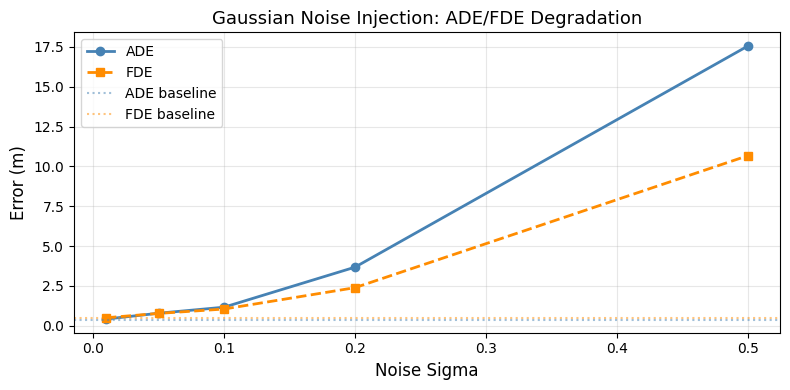

In [21]:
SAVE_DIR = './results/stress_tests/'
os.makedirs(SAVE_DIR, exist_ok=True)

# Plot 1: Noise injection degradation
fig, ax = plt.subplots(figsize=(8, 4))
sigmas = list(noise_results.keys())
ade_vals = [noise_results[s]['ADE'] for s in sigmas]
fde_vals = [noise_results[s]['FDE'] for s in sigmas]

ax.plot(sigmas, ade_vals, 'o-', color='steelblue', label='ADE', linewidth=2)
ax.plot(sigmas, fde_vals, 's--', color='darkorange', label='FDE', linewidth=2)
ax.axhline(baseline_results['ADE'], color='steelblue', linestyle=':', alpha=0.5, label='ADE baseline')
ax.axhline(baseline_results['FDE'], color='darkorange', linestyle=':', alpha=0.5, label='FDE baseline')
ax.set_xlabel('Noise Sigma', fontsize=12)
ax.set_ylabel('Error (m)', fontsize=12)
ax.set_title('Gaussian Noise Injection: ADE/FDE Degradation', fontsize=13)
ax.legend(fontsize=10)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig(f'{SAVE_DIR}/noise_degradation.png', dpi=150)
plt.show()

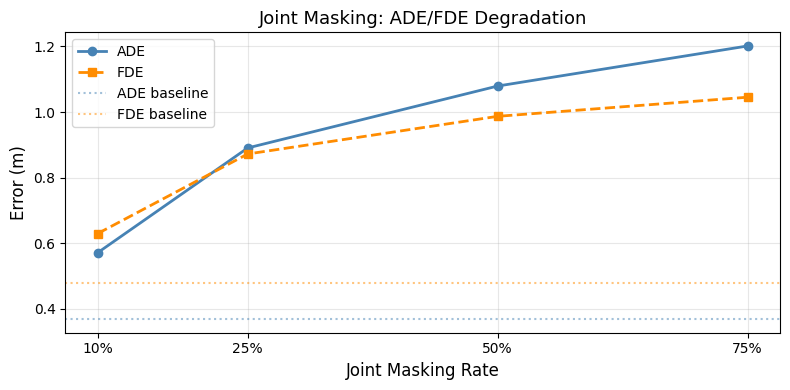

In [22]:
# Plot 2: Joint masking degradation
fig, ax = plt.subplots(figsize=(8, 4))
rates = list(mask_results.keys())
ade_vals = [mask_results[r]['ADE'] for r in rates]
fde_vals = [mask_results[r]['FDE'] for r in rates]
rate_labels = [f'{r:.0%}' for r in rates]

ax.plot(rates, ade_vals, 'o-', color='steelblue', label='ADE', linewidth=2)
ax.plot(rates, fde_vals, 's--', color='darkorange', label='FDE', linewidth=2)
ax.axhline(baseline_results['ADE'], color='steelblue', linestyle=':', alpha=0.5, label='ADE baseline')
ax.axhline(baseline_results['FDE'], color='darkorange', linestyle=':', alpha=0.5, label='FDE baseline')
ax.set_xlabel('Joint Masking Rate', fontsize=12)
ax.set_ylabel('Error (m)', fontsize=12)
ax.set_title('Joint Masking: ADE/FDE Degradation', fontsize=13)
ax.set_xticks(rates)
ax.set_xticklabels(rate_labels)
ax.legend(fontsize=10)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig(f'{SAVE_DIR}/mask_degradation.png', dpi=150)
plt.show()

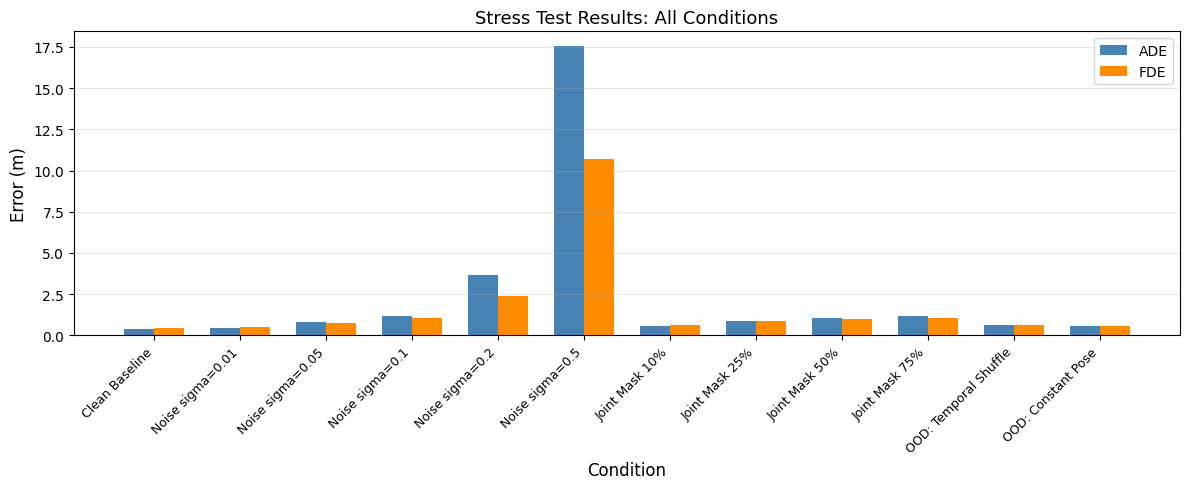

In [23]:
# Plot 3: All conditions bar chart
fig, ax = plt.subplots(figsize=(12, 5))

conditions = df_stress['Condition'].tolist()
ade_all = df_stress['ADE'].tolist()
fde_all = df_stress['FDE'].tolist()
x = np.arange(len(conditions))
width = 0.35

bars1 = ax.bar(x - width/2, ade_all, width, label='ADE', color='steelblue')
bars2 = ax.bar(x + width/2, fde_all, width, label='FDE', color='darkorange')

ax.set_xlabel('Condition', fontsize=12)
ax.set_ylabel('Error (m)', fontsize=12)
ax.set_title('Stress Test Results: All Conditions', fontsize=13)
ax.set_xticks(x)
ax.set_xticklabels(conditions, rotation=45, ha='right', fontsize=9)
ax.legend(fontsize=10)
ax.grid(True, alpha=0.3, axis='y')
plt.tight_layout()
plt.savefig(f'{SAVE_DIR}/all_conditions_bar.png', dpi=150)
plt.show()

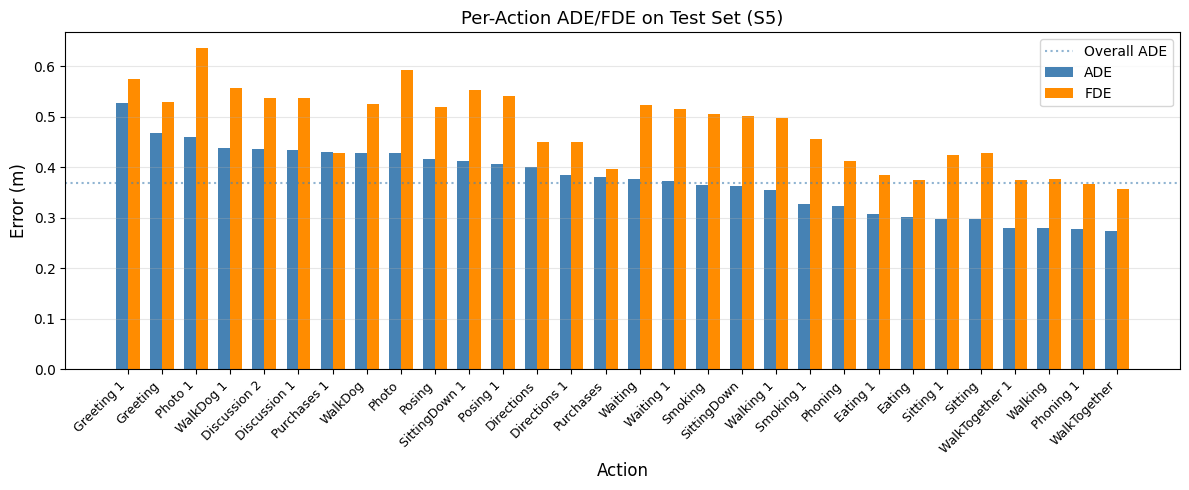

In [24]:
# Plot 4: Per-action ADE bar chart
fig, ax = plt.subplots(figsize=(12, 5))

act_names = df_actions['Action'].tolist()
act_ade = df_actions['ADE'].tolist()
act_fde = df_actions['FDE'].tolist()
x = np.arange(len(act_names))
width = 0.35

ax.bar(x - width/2, act_ade, width, label='ADE', color='steelblue')
ax.bar(x + width/2, act_fde, width, label='FDE', color='darkorange')
ax.axhline(baseline_results['ADE'], color='steelblue', linestyle=':', alpha=0.6, label='Overall ADE')
ax.set_xlabel('Action', fontsize=12)
ax.set_ylabel('Error (m)', fontsize=12)
ax.set_title('Per-Action ADE/FDE on Test Set (S5)', fontsize=13)
ax.set_xticks(x)
ax.set_xticklabels(act_names, rotation=45, ha='right', fontsize=9)
ax.legend(fontsize=10)
ax.grid(True, alpha=0.3, axis='y')
plt.tight_layout()
plt.savefig(f'{SAVE_DIR}/per_action_metrics.png', dpi=150)
plt.show()

## Section 13: Failure Case Examples

Select the top-10 worst-performing sequences from the clean baseline evaluation (highest per-sequence ADE). For each, we record the sequence index, its ADE, FDE, and the relative degradation. These examples will form the curated failure table in the report (Section 8.2.4), showing input characteristics, predicted vs. expected output, and potential mitigation ideas.

In [25]:
# Top-10 worst sequences by ADE (clean baseline)
worst_indices = np.argsort(baseline_per_ade)[-10:][::-1]

failure_rows = []
for idx in worst_indices:
    failure_rows.append({
        'Seq Index': idx,
        'ADE': baseline_per_ade[idx],
        'FDE': baseline_per_fde[idx],
        'ADE / Mean': baseline_per_ade[idx] / baseline_results['ADE'],
    })

df_failures = pd.DataFrame(failure_rows).round(4)
print('Top-10 Worst Sequences (Clean Baseline):')
print(df_failures.to_string(index=False))

Top-10 Worst Sequences (Clean Baseline):
 Seq Index    ADE    FDE  ADE / Mean
      4897 1.4190 1.2216      3.8445
      1575 1.3523 2.0091      3.6639
      4854 1.2230 1.2480      3.3135
      1559 1.1578 1.3576      3.1367
      2383 1.1453 1.9389      3.1029
      4899 1.1043 1.7416      2.9917
      4853 1.0866 1.2786      2.9440
      2213 1.0836 1.6862      2.9357
      2222 1.0787 1.5609      2.9225
      1567 1.0698 1.0718      2.8984


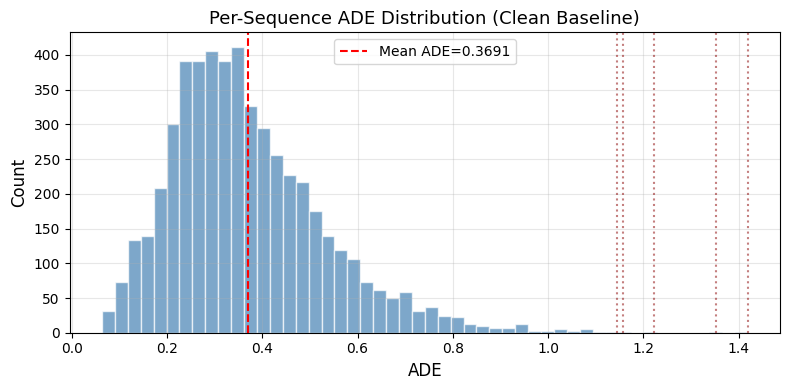

In [26]:
# Per-sequence ADE distribution histogram
fig, ax = plt.subplots(figsize=(8, 4))
ax.hist(baseline_per_ade, bins=50, color='steelblue', alpha=0.7, edgecolor='white')
ax.axvline(baseline_results['ADE'], color='red', linestyle='--', linewidth=1.5, label=f'Mean ADE={baseline_results["ADE"]:.4f}')
# Mark worst cases
for idx in worst_indices[:5]:
    ax.axvline(baseline_per_ade[idx], color='darkred', linestyle=':', alpha=0.5)
ax.set_xlabel('ADE', fontsize=12)
ax.set_ylabel('Count', fontsize=12)
ax.set_title('Per-Sequence ADE Distribution (Clean Baseline)', fontsize=13)
ax.legend(fontsize=10)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig(f'{SAVE_DIR}/ade_distribution.png', dpi=150)
plt.show()

## Section 14: Latency Distribution Plot

Histogram of single-sequence inference latencies from the benchmarking in Section 10. Vertical lines mark p50 and p90 percentiles.

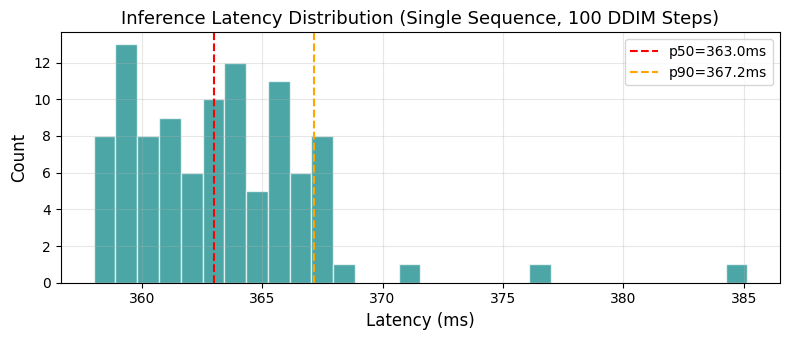

In [27]:
fig, ax = plt.subplots(figsize=(8, 3.5))
ax.hist(latencies, bins=30, color='teal', alpha=0.7, edgecolor='white')
ax.axvline(np.percentile(latencies, 50), color='red', linestyle='--', linewidth=1.5,
           label=f'p50={np.percentile(latencies, 50):.1f}ms')
ax.axvline(np.percentile(latencies, 90), color='orange', linestyle='--', linewidth=1.5,
           label=f'p90={np.percentile(latencies, 90):.1f}ms')
ax.set_xlabel('Latency (ms)', fontsize=12)
ax.set_ylabel('Count', fontsize=12)
ax.set_title('Inference Latency Distribution (Single Sequence, 100 DDIM Steps)', fontsize=13)
ax.legend(fontsize=10)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig(f'{SAVE_DIR}/latency_distribution.png', dpi=150)
plt.show()

## Section 15: Save Results

Export all results as CSV files for reproducibility and report generation.

In [28]:
df_stress.to_csv(f'{SAVE_DIR}/stress_test_results.csv', index=False)
df_actions.to_csv(f'{SAVE_DIR}/per_action_results.csv', index=False)
df_failures.to_csv(f'{SAVE_DIR}/failure_cases.csv', index=False)

# Save latency results
latency_summary = pd.DataFrame([{
    'metric': 'single_seq',
    'p50_ms': np.percentile(latencies, 50),
    'p90_ms': np.percentile(latencies, 90),
    'p99_ms': np.percentile(latencies, 99),
    'mean_ms': latencies.mean(),
    'std_ms': latencies.std(),
    'throughput_seq_per_s': 1000 / latencies.mean()
}])
for bs, vals in batch_latencies.items():
    latency_summary = pd.concat([latency_summary, pd.DataFrame([{
        'metric': f'batch_{bs}',
        'p50_ms': vals['p50_ms'],
        'p90_ms': vals['p90_ms'],
        'throughput_seq_per_s': vals['throughput']
    }])], ignore_index=True)

latency_summary.to_csv(f'{SAVE_DIR}/latency_results.csv', index=False)

print(f'Results saved to {SAVE_DIR}')
print('Files: stress_test_results.csv, per_action_results.csv, failure_cases.csv, latency_results.csv')

Results saved to ./results/stress_tests/
Files: stress_test_results.csv, per_action_results.csv, failure_cases.csv, latency_results.csv
